# Bayesian network: Cloud, Sprinkler, Rain, Grass

We use the directed network from the notes:

$C\to S,\qquad C\to R,\qquad S\to G,\qquad R\to G.$

The joint distribution is computed from Bayes' rule:

$$p(C,S,R,G)=p(C)p(S\mid C)p(R\mid C)p(G\mid S,R).$$

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# State order used in the notes: (C, S, R, G), each variable is in {-1, +1}.
states = np.array(list(itertools.product([-1, 1], repeat=4)))
labels = [''.join('+' if x == 1 else '-' for x in state) for state in states]


def p_plus(input_value):
    return (1 + np.tanh(input_value)) / 2


def exact_probability(state):
    C, S, R, G = state
    p_C = 0.5
    p_S_given_C = (1 + S * np.tanh(-C)) / 2
    p_R_given_C = (1 + R * np.tanh(C)) / 2
    p_G_given_SR = (1 + G * np.tanh(R + 2 * S)) / 2
    return p_C * p_S_given_C * p_R_given_C * p_G_given_SR


exact = np.array([exact_probability(state) for state in states])
exact = exact / exact.sum()

for label, probability in zip(labels, exact):
    print(f'{label}: {probability:.6f}')

print(f'\nsum = {exact.sum():.6f}')

----: 0.052367
---+: 0.000130
--+-: 0.006258
--++: 0.000847
-+--: 0.046239
-+-+: 0.341663
-++-: 0.000130
-+++: 0.052367
+---: 0.052367
+--+: 0.000130
+-+-: 0.341663
+-++: 0.046239
++--: 0.000847
++-+: 0.006258
+++-: 0.000130
++++: 0.052367

sum = 1.000000


Parent-to-child sampling is important here. We sample $C$ first, then $S$ and $R$, then $G$. This is ancestral sampling for the Bayesian network.

In [2]:
def draw_binary(prob_plus_value):
    return 1 if rng.random() < prob_plus_value else -1


def sample_parent_to_child(num_samples=100_000):
    samples = np.empty((num_samples, 4), dtype=int)

    for n in range(num_samples):
        # Root node.
        C = draw_binary(0.5)

        # Children of C.
        S = draw_binary(p_plus(-C))
        R = draw_binary(p_plus(C))

        # Child of S and R.
        G = draw_binary(p_plus(R + 2 * S))

        samples[n] = [C, S, R, G]

    return samples


samples = sample_parent_to_child(num_samples=200_000)
empirical = np.array([np.all(samples == state, axis=1).mean() for state in states])

for label, e, b in zip(labels, empirical, exact):
    print(f'{label}: sample={e:.6f}, bayes={b:.6f}, diff={e-b:+.6f}')

----: sample=0.051940, bayes=0.052367, diff=-0.000427
---+: sample=0.000075, bayes=0.000130, diff=-0.000055
--+-: sample=0.006340, bayes=0.006258, diff=+0.000082
--++: sample=0.000815, bayes=0.000847, diff=-0.000032
-+--: sample=0.045785, bayes=0.046239, diff=-0.000454
-+-+: sample=0.342600, bayes=0.341663, diff=+0.000937
-++-: sample=0.000195, bayes=0.000130, diff=+0.000065
-+++: sample=0.051790, bayes=0.052367, diff=-0.000577
+---: sample=0.052305, bayes=0.052367, diff=-0.000062
+--+: sample=0.000150, bayes=0.000130, diff=+0.000020
+-+-: sample=0.342510, bayes=0.341663, diff=+0.000847
+-++: sample=0.046330, bayes=0.046239, diff=+0.000091
++--: sample=0.000870, bayes=0.000847, diff=+0.000023
++-+: sample=0.006315, bayes=0.006258, diff=+0.000057
+++-: sample=0.000160, bayes=0.000130, diff=+0.000030
++++: sample=0.051820, bayes=0.052367, diff=-0.000547


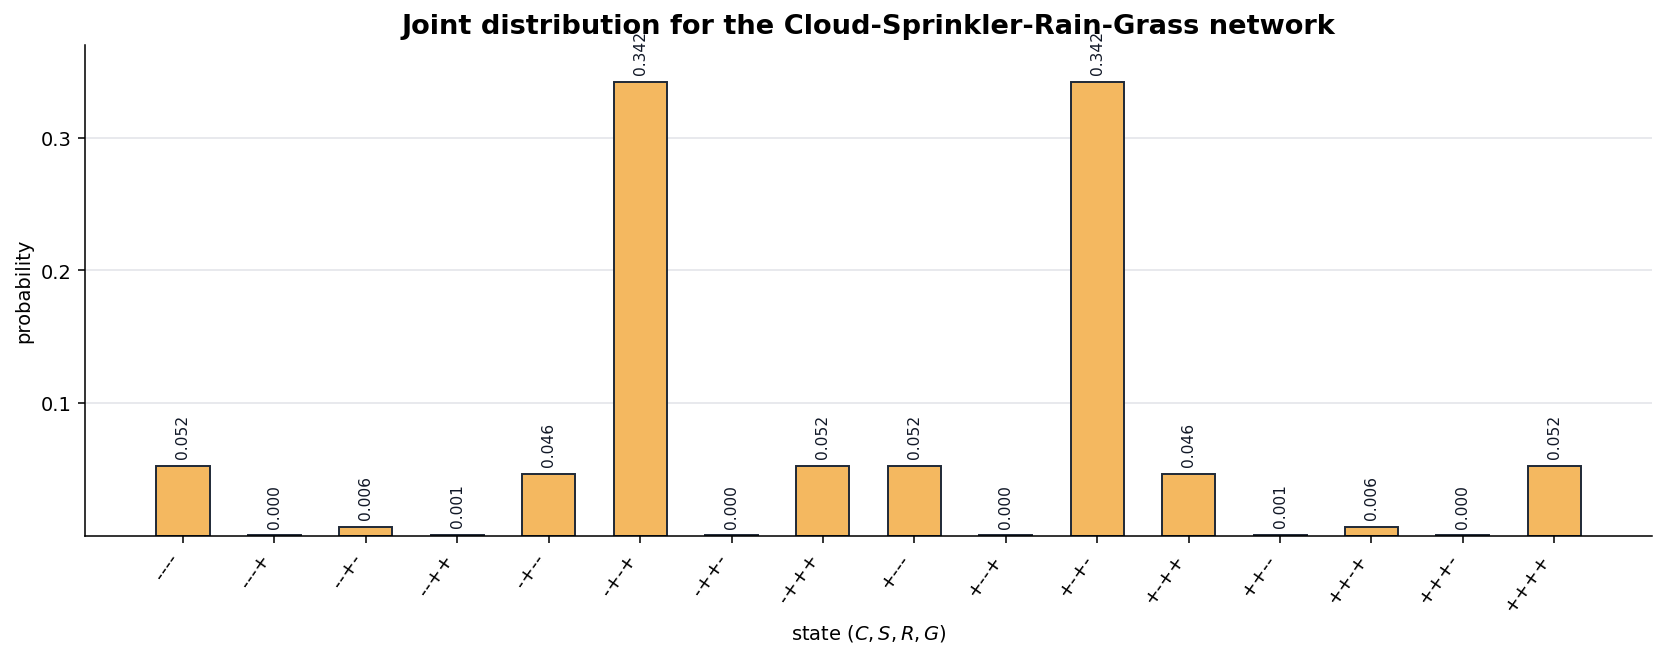

In [4]:
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(12, 4.8), dpi=140)
bars = ax.bar(
    x,
    exact,
    width=0.58,
    color='#f4b860',
    edgecolor='#1f2937',
    linewidth=1.0,
)

for bar, probability in zip(bars, exact):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        probability + 0.006,
        f'{probability:.3f}',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=90,
        color='#111827',
    )

ax.set_title('Joint distribution for the Cloud-Sprinkler-Rain-Grass network', fontsize=14, weight='bold')
ax.set_xlabel('state $(C,S,R,G)$')
ax.set_ylabel('probability')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=55, ha='right')
ax.set_ylim(0, 0.37)
ax.set_yticks([0.10, 0.20, 0.30])
ax.grid(axis='y', color='#e5e7eb', linewidth=0.9)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

If we update in a random order instead of parent-to-child order, we still define a Markov chain, but it generally does not sample the Bayesian joint distribution above.